In [1]:
import glob
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
import h5py
import sys
import os
import numpy as np
import logging

In [2]:
def D_JS(p1,p2,tol=1e-16):
    p1=p1/np.sum(p1)
    p2=p2/np.sum(p2)
    pm = (p1+p2)/2
    p1_nonzero = np.abs(p1)>tol
    p2_nonzero = np.abs(p2)>tol
    p1  = np.abs(p1[p1_nonzero])
    pm1 = np.abs(pm[p1_nonzero])
    p2  = np.abs(p2[p2_nonzero])
    pm2 = np.abs(pm[p2_nonzero])
    d = .5*( (p1*np.log(p1/pm1)).sum() + (p2*np.log(p2/pm2)).sum() )
    d /= np.log(2) # normalize to max of 1
    return d

In [3]:

qmc_algo_path = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/qmc_algo_tools') 
dev = os.path.abspath('/pscratch/sd/k/kberard/SCGSR/3D_VMC/Model_Train_dat/FFT_Jaron/developer_tools') 

sys.path.insert(0, qmc_algo_path) 
sys.path.insert(0, dev) 

with h5py.File('/global/u2/k/kberard/SCGSR/Research/Diamond/Data/density_tot_ref.h5', 'r') as file:
    dft_d = file['density'][:]
with h5py.File('/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2/density_tot_ref_mean.h5', 'r') as file:
    VMC_ref = file['density'][:]
DFT_vs_VMC = D_JS(VMC_ref, dft_d)
print(DFT_vs_VMC)   

0.00012671965457473964


Found 33 noisy files.


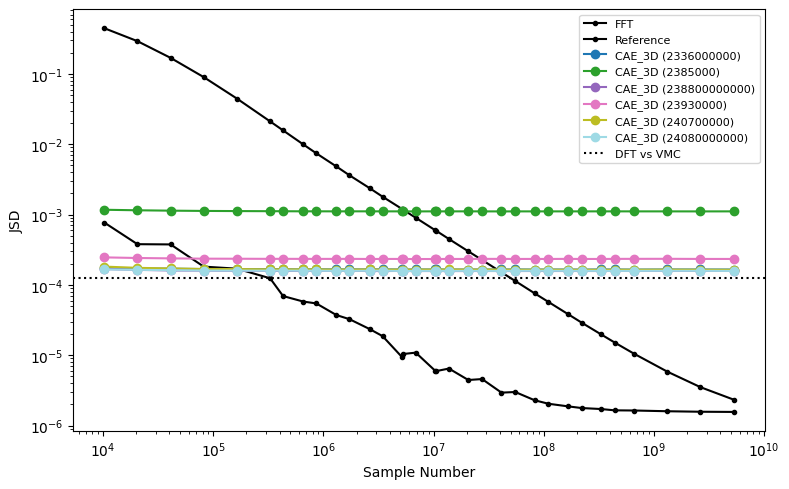

In [4]:


# === Load data ===
data = np.load("/pscratch/sd/k/kberard/SCGSR/EDDA/Data_Gen/plot_data/jsd_plot_data_3D.npz", allow_pickle=True)

# If it's a dict stored in arr_0
if "arr_0" in data:
    jsd_dict = data["arr_0"].item()
else:
    jsd_dict = {k: data[k] for k in data.files}

# Extract reference




# ================= Paths & Models =================
base_dir = "/pscratch/sd/k/kberard/SCGSR/Data/diamond_1x1x1_bfd/density_data/vmc_J2"
ref_path = os.path.join(base_dir, "density_tot_ref_mean.h5")

#print(ref_d)

noisy_files = sorted(glob.glob(os.path.join(base_dir, "density_tot_vmc_mean*.h5")))

print(f"Found {len(noisy_files)} noisy files.")


# ================= Reference JSD =================
results_ref = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))

    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]
    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]

    jsd = D_JS(ref_d, test_d)
    results_ref.append((sample_num, jsd))

results_array_ref = np.array(sorted(results_ref, key=lambda x: x[0]))



#! /usr/bin/env python3

#from qmc_algo_tools.density_data import DensityData
from qmc_algo_tools.density_denoise import DensityFourierFilterErrorCeil
#from qmc_algo_tools.density_denoise import D_JS


model_results_FFT = []
for noisy_path in noisy_files:
    match = re.search(r"(\d+)\.h5$", noisy_path)
    if not match:
        continue
    sample_num = int(match.group(1))
    with h5py.File(ref_path, 'r') as file:
        ref_d = file['density'][:]

    with h5py.File(noisy_path, 'r') as file:
        test_d = file['density'][:]
    dm = DensityFourierFilterErrorCeil(density_ref= dft_d,filter_mode='augment')

    d_denoised = dm.denoise(test_d)
    jsd_denoised = D_JS(d_denoised, VMC_ref)
    model_results_FFT.append((sample_num, jsd_denoised))
    


# Extract models (rename keys for cleaner labels)
all_results = {}
for k, v in jsd_dict.items():
    if k != "results_array_ref":
        # Strip off trailing "CAE_3D" and put it in parentheses
        if k.endswith("CAE_3D"):
            prefix = k.replace("CAE_3D", "")
            clean_name = f"CAE_3D ({prefix})"
        else:
            clean_name = k
        all_results[clean_name] = v
x_values, y_values = zip(*model_results_FFT)
# === Plot ===
logging.getLogger('matplotlib').setLevel(logging.WARNING)
plt.figure(figsize=(8, 5))

plt.loglog(x_values, y_values,
           marker=".",             # Dot markers
           linestyle="-",          # Solid connecting line
           color="black", 
           label="FFT")

# Plot reference
plt.loglog(results_array_ref[:, 0], results_array_ref[:, 1],
           marker=".", linestyle="-", color="black", label="Reference")

# Plot all CAE_3D models
colors = plt.cm.tab20(np.linspace(0, 1, len(all_results)))
for color, (name, data) in zip(colors, all_results.items()):
    plt.loglog(data[:, 0], data[:, 1],
               marker="o", linestyle="-", label=name, color=color)

plt.xlabel("Sample Number")
plt.ylabel("JSD")
plt.axhline(DFT_vs_VMC, color="black", linestyle=":", label="DFT vs VMC")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()
